In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce') # pandas의 to_datetime 검색해서 사용법 잘 봐 두고
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [ ]:
# 문제 1: 고객별 RFM 점수를 계산하고, 고객을 'VIP', '우수고객', '일반고객', '이탈위험고객'으로 분류하세요.
# 시각화: 바 차트 

# 비즈니스 목적: 고객을 가치에 따라 세분화하고, 그룹별로 맞춤형 마케팅을 진행하여 고객 관계를 강화합니다.
# RFM 검색해서 풀어라

###### 출력 결과를 보고 코딩하세요
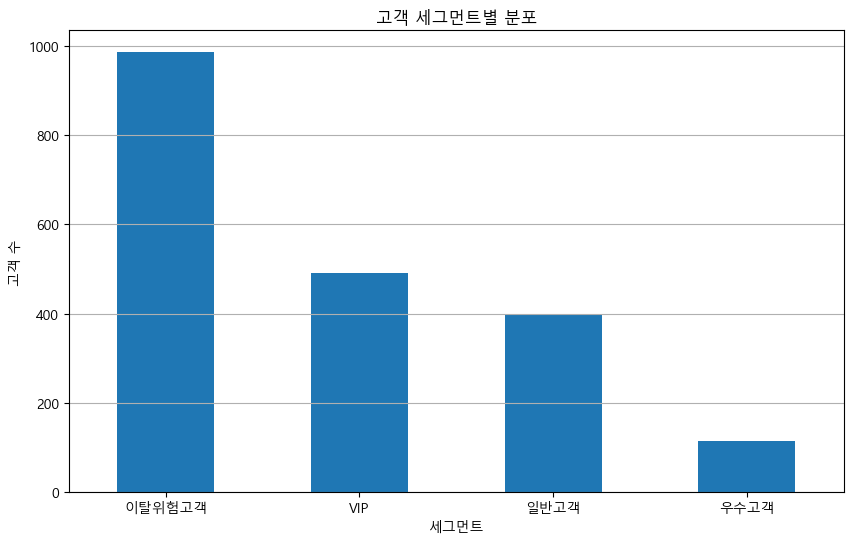


In [3]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'order_date', 'quantity',
       'payment_id', 'payment_method', 'payment_status', 'payment_date',
       'product_name', 'category', 'price', 'stock', 'name', 'gender', 'age',
       'join_date', 'city', 'shipping_id', 'shipping_company',
       'shipping_status', 'shipping_start_date', 'shipping_end_date',
       'total_sales'],
      dtype='object')

📊 RFM이란?
RFM은 고객 가치를 평가하는 3가지 지표의 약자입니다:
1. R (Recency) - 최근성
"얼마나 최근에 구매했는가?"
마지막 구매일로부터 경과한 일수
값이 작을수록 좋음 (최근에 구매한 고객)
예: 3일 전 구매 > 100일 전 구매

2. F (Frequency) - 빈도
"얼마나 자주 구매하는가?"
총 구매 횟수
값이 클수록 좋음 (자주 구매하는 고객)
예: 10회 구매 > 2회 구매

3. M (Monetary) - 금액
"얼마나 많은 돈을 쓰는가?"
총 구매 금액
값이 클수록 좋음 (많이 지출하는 고객)
예: 100만원 > 10만원

💡 RFM 점수 계산 방법
일반적으로 각 지표를 1~5점 또는 1~4점으로 등급화합니다:
``` python
# 예시: 5점 척도
R: 5점(매우 최근) ~ 1점(오래됨)
F: 5점(매우 자주) ~ 1점(가끔)
M: 5점(많이 씀) ~ 1점(적게 씀)

# 총 RFM 점수 = R점수 + F점수 + M점수
# 최고: 555 (15점)
# 최저: 111 (3점)
```


In [9]:
# RFM 필요한 컬럼만 선택해서 복사
df_quest21 = df[['customer_id', 'order_id', 'order_date', 'total_sales']].copy()

# 기준 날짜 설정 (분석 시점 = 최종 주문일로)
analysis_date = df_quest21['order_date'].max()

# 1. 고객별 RFM 값 계산
df_rfm = df_quest21.groupby('customer_id').agg({
    'order_date': lambda x: (analysis_date - x.max()).days,   # Recency
    'order_id': 'count',                                      # Frequency
    'total_sales': 'sum'                                      # Monetary
}).reset_index()

df_rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']
df_rfm.describe()

,Recency,Frequency,Monetary
count,1990.000000,1990.000000,1.990000e+03
mean,140.140201,5.025126,8.292749e+05
std,132.958250,2.212304,4.454528e+05
min,0.000000,1.000000,1.260000e+04
25%,40.000000,3.000000,5.088500e+05
50%,100.000000,5.000000,7.812000e+05
75%,198.750000,6.000000,1.089250e+06
max,687.000000,15.000000,2.894100e+06


In [ ]:
# 세그먼트 라벨 정의 (이탈위험 -> 일반 -> 우수 -> VIP 순서)
segment_labels = ['이탈위험고객', '일반고객', '우수고객', 'VIP']

# R, F, M 각각 1~4점으로 점수화 (qcut 사용)
# Recency: 낮을수록 좋음 → 역순 점수 (1~4점)
# df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 4, labels=[4, 3, 2, 1], duplicates='drop')
# df_rfm['R_Score'] = pd.cut(df_rfm['Recency'], 
#                             bins=[-1, 30, 90, 180, float('inf')],  # 30일, 90일, 180일 기준
#                             labels=['VIP', '우수고객', '일반고객', '이탈위험고객'])

df_rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score
0,C0001,187,7,1020900,2
1,C0002,20,3,848600,4
2,C0003,39,2,600800,4
3,C0004,40,2,431600,4
4,C0005,67,3,628000,3


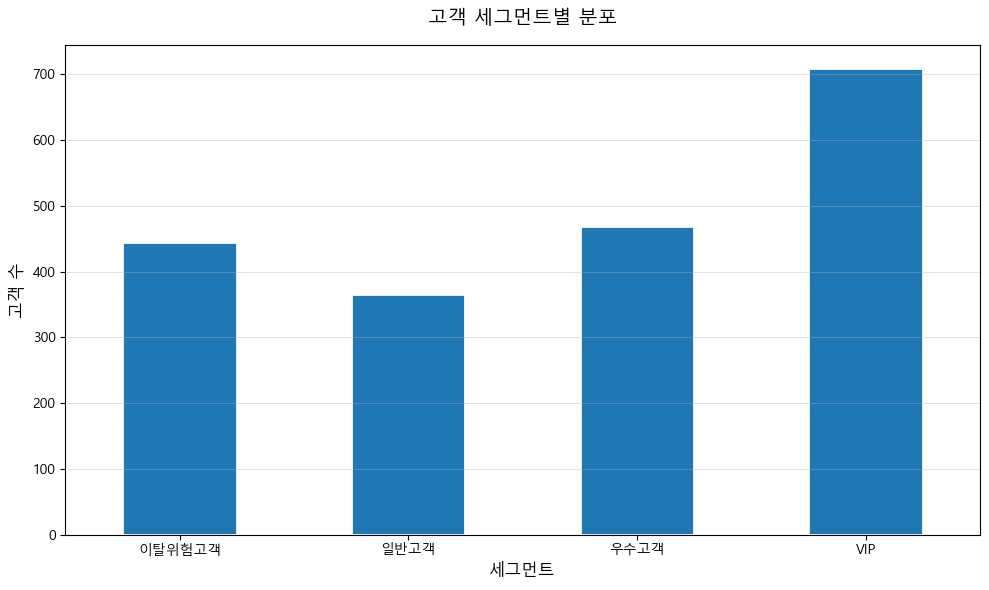

In [ ]:

# Frequency: 높을수록 좋음 → 정순 점수 (1~4점)
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 4, 
                             labels=[1, 2, 3, 4], duplicates='drop')

# Monetary: 높을수록 좋음 → 정순 점수 (1~4점)
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'].rank(method='first'), 4, 
                             labels=[1, 2, 3, 4], duplicates='drop')


# 최종 세그먼트 결정: R, F, M 중 최빈값 선택
# df_rfm['Segment'] = df_rfm[['R_Score', 'F_Score', 'M_Score']].mode(axis=1)[0]

# 그래프용 DataFrame 생성
# value_counts()로 세그먼트별 고객 수 집계
# reindex()로 segment_labels 순서대로 재정렬 (없는 세그먼트는 0으로 채움)
# to_frame()으로 Series를 DataFrame으로 변환
df_plot = df_rfm['Segment'].value_counts().reindex(segment_labels, fill_value=0).to_frame()
df_plot.columns = ['고객 수']  # 컬럼명 지정

# 바 차트 시각화
ax = df_plot.plot(kind='bar',              # 바 차트 유형
                  figsize=(10, 6),         # 그래프 크기
                  color='#1f77b4',         # 파란색
                  edgecolor='white',       # 바 테두리 색상
                  linewidth=2,             # 테두리 두께
                  legend=False)            # 범례 숨김

# 그래프 제목 및 축 레이블 설정
ax.set_title('고객 세그먼트별 분포', fontsize=14, pad=15)
ax.set_xlabel('세그먼트', fontsize=12)
ax.set_ylabel('고객 수', fontsize=12)

# y축 격자선 추가 (가독성 향상)
ax.grid(axis='y', alpha=0.5, linestyle='-', linewidth=0.5)

# x축 라벨 회전 없음 (수평으로 표시)
plt.xticks(rotation=0)

# 여백 자동 조정
plt.tight_layout()

# 그래프 출력
plt.show()